In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math

torch.manual_seed(42)
np.random.seed(42)

In [12]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores / 0.1)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores / 0.1)

In [13]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 128)
        self.fc4 = PrunableLinear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

    def get_sparsity_loss(self):
        loss = 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates = m.get_gates()
                loss += torch.mean(gates ** 2)
        return loss

    def get_sparsity_level(self, threshold=0.2):
        total = 0
        pruned = 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates = m.get_gates().detach()
                total += gates.numel()
                pruned += (gates < threshold).sum().item()
        return 100.0 * pruned / total

    def get_all_gates(self):
        all_gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                all_gates.append(m.get_gates().detach().cpu().flatten())
        return torch.cat(all_gates)

In [14]:
def get_data_loaders(batch_size=256):
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])

    train_set = datasets.CIFAR10('./data', train=True, download=True, transform=transform_train)
    test_set = datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, test_loader

In [15]:
def train_one_epoch(model, loader, optimizer, lambda_val, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for data, target in loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)

        cls_loss = F.cross_entropy(output, target)
        sparsity_loss = model.get_sparsity_loss()
        loss = cls_loss + lambda_val * sparsity_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

    return 100.0 * correct / total

In [16]:
def run_experiment(lambda_val, train_loader, test_loader, device, epochs=30):
    print(f"\n{'='*50}")
    print(f"Training with λ = {lambda_val}")
    print(f"{'='*50}")

    model = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, epochs+1):
        loss, acc = train_one_epoch(model, train_loader, optimizer, lambda_val, device)

        if epoch % 5 == 0 or epoch == 1:
            sparsity = model.get_sparsity_level()
            print(f"Epoch {epoch:2d} | Loss {loss:.4f} | Acc {acc:.2f}% | Sparsity {sparsity:.2f}%")

    test_acc = evaluate(model, test_loader, device)
    sparsity = model.get_sparsity_level()
    gates = model.get_all_gates()

    print(f"\nFINAL → Acc: {test_acc:.2f}% | Sparsity: {sparsity:.2f}%")
    return test_acc, sparsity, gates, model

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

train_loader, test_loader = get_data_loaders()

lambdas = [0.1, 0.5, 1.0]

results = {}

for lam in lambdas:
    acc, sparsity, gates, model = run_experiment(lam, train_loader, test_loader, device)
    results[lam] = {'test_acc': acc, 'sparsity': sparsity, 'gates': gates}

Using device: cuda

Training with λ = 0.1
Epoch  1 | Loss 1.9982 | Acc 30.69% | Sparsity 10.36%
Epoch  5 | Loss 1.6433 | Acc 43.70% | Sparsity 16.45%
Epoch 10 | Loss 1.5341 | Acc 47.13% | Sparsity 23.49%
Epoch 15 | Loss 1.4788 | Acc 48.87% | Sparsity 29.87%
Epoch 20 | Loss 1.4387 | Acc 50.23% | Sparsity 35.59%
Epoch 25 | Loss 1.4021 | Acc 51.18% | Sparsity 40.51%
Epoch 30 | Loss 1.3788 | Acc 52.20% | Sparsity 44.72%

FINAL → Acc: 53.59% | Sparsity: 44.72%

Training with λ = 0.5
Epoch  1 | Loss 2.3332 | Acc 29.92% | Sparsity 15.12%
Epoch  5 | Loss 1.7536 | Acc 43.35% | Sparsity 36.42%
Epoch 10 | Loss 1.6054 | Acc 46.69% | Sparsity 51.93%
Epoch 15 | Loss 1.5281 | Acc 48.60% | Sparsity 60.69%
Epoch 20 | Loss 1.4723 | Acc 50.18% | Sparsity 66.01%
Epoch 25 | Loss 1.4366 | Acc 51.07% | Sparsity 69.62%
Epoch 30 | Loss 1.4093 | Acc 52.00% | Sparsity 72.25%

FINAL → Acc: 53.24% | Sparsity: 72.25%

Training with λ = 1.0
Epoch  1 | Loss 2.6864 | Acc 29.65% | Sparsity 21.13%
Epoch  5 | Loss 1.7975

In [18]:
print("\n" + "="*55)
print(f"{'Lambda':<10} {'Accuracy':<15} {'Sparsity'}")
print("="*55)

for lam, res in results.items():
    print(f"{lam:<10} {res['test_acc']:.2f}%{'':<8} {res['sparsity']:.2f}%")

print("="*55)


Lambda     Accuracy        Sparsity
0.1        53.59%         44.72%
0.5        53.24%         72.25%
1.0        53.55%         83.92%


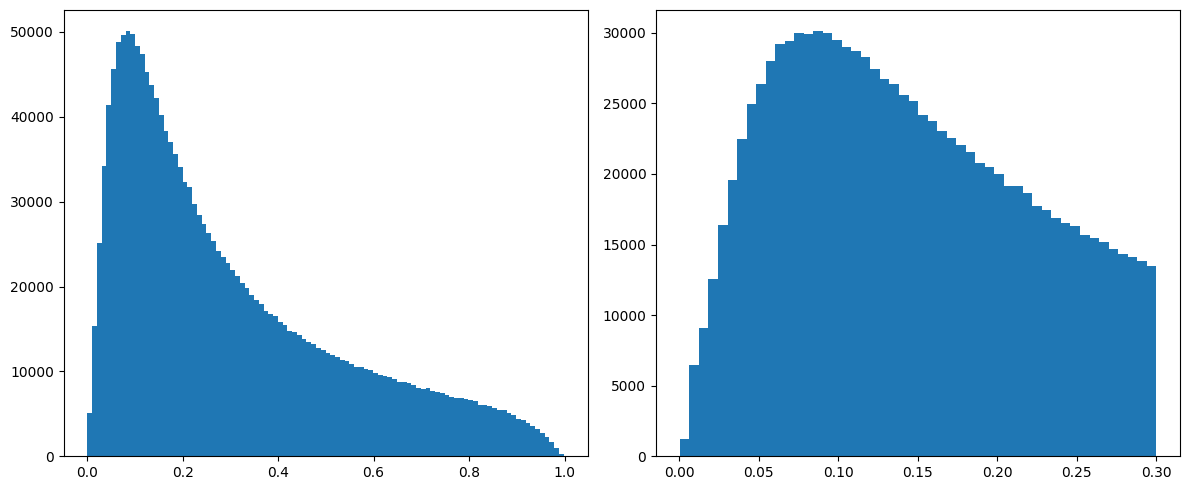

In [19]:
best_lam = max(results, key=lambda l: results[l]['test_acc'])
gates = results[best_lam]['gates'].cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(gates, bins=100)

plt.subplot(1,2,2)
plt.hist(gates[gates < 0.3], bins=50)

plt.tight_layout()
plt.show()